# 10 — Pose-graph SLAM & loop closure

specter-1's SLAM substrate switched from local scan-match (NB 06) to a
full **pose-graph optimizer** in ADRs 0016–0017. This notebook is the
intuition for that change:

- A pose graph is a factor graph over *poses* (`Pose2`) connected by
  *constraints* (odometry, landmark observations, inter-robot, loop
  closures).
- Each constraint is a residual; the optimizer (Levenberg–Marquardt over
  SE(2) tangent space) shifts the poses to minimise total χ².
- A **single** loop-closure factor — added when the agent re-observes a
  prior landmark — redistributes accumulated odometry drift backward
  through *every* pose between the two endpoints.

This is the same code the L09 Workshop canvas drives, just stripped to
its essentials.


## Operator question

**Why bother with a global solve when local scan-match already gives me
a metric trajectory?**

Because scan-match's drift is *unbounded over time* — every tick adds a
small angular error that compounds. A single loop closure constraint
collapses that error globally: the optimizer has *every* pose in the
loop to spread the correction across, instead of carrying it forward.
That's what makes pose-graph SLAM the prerequisite for trust-layer SLAM
integration (NB 11–12).


In [1]:
%matplotlib inline
import math
import os
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(_root)

import numpy as np
import matplotlib.pyplot as plt

from specter.slam.pose_graph import (
    PoseGraph,
    Pose2,
    OdometryFactor,
    LoopClosureFactor,
    odometry_information,
)


## Intuition — drift, then snap

Build a 20-pose closed-loop trajectory: a square, four sides of five
poses each. The odometry constraint between consecutive poses is
**slightly biased** so that integrating round the loop accumulates a
gap. We then add one loop-closure factor between the last pose and
`p0` and re-optimise.


In [2]:
N_SIDE = 5
SIDE_LEN = 4.0  # metres per leg
DRIFT_PER_STEP = (0.0, 0.0, 0.02)  # tiny θ bias → curls the integrated path

# 1. Build the ground-truth square — four straight legs of N_SIDE poses each.
truth = []
heading = 0.0
x, y = 0.0, 0.0
truth.append(Pose2(x, y, heading))
for leg in range(4):
    for _ in range(N_SIDE):
        x += SIDE_LEN * math.cos(heading)
        y += SIDE_LEN * math.sin(heading)
        truth.append(Pose2(x, y, heading))
    heading += math.pi / 2  # 90° turn between legs

# 2. Build odometry with a tiny θ bias on every step.
odom = []
for i in range(len(truth) - 1):
    dx = SIDE_LEN if (i % N_SIDE) != (N_SIDE - 1) or i == 0 else SIDE_LEN
    dxi = (SIDE_LEN, 0.0, 0.0) if (i + 1) % N_SIDE != 0 else (SIDE_LEN, 0.0, math.pi / 2)
    dxi = (dxi[0] + DRIFT_PER_STEP[0], dxi[1] + DRIFT_PER_STEP[1], dxi[2] + DRIFT_PER_STEP[2])
    odom.append(dxi)

# 3. Pre-optimization estimate: integrate the noisy odometry from p0.
def integrate(deltas):
    poses = [Pose2(0.0, 0.0, 0.0)]
    for d in deltas:
        prev = poses[-1]
        nx = prev.x + d[0] * math.cos(prev.theta) - d[1] * math.sin(prev.theta)
        ny = prev.y + d[0] * math.sin(prev.theta) + d[1] * math.cos(prev.theta)
        nt = prev.theta + d[2]
        poses.append(Pose2(nx, ny, nt))
    return poses

pre = integrate(odom)
gap_before = math.hypot(pre[-1].x - pre[0].x, pre[-1].y - pre[0].y)
print(f"dead-reckoned gap (last vs first pose): {gap_before:.3f} m")


dead-reckoned gap (last vs first pose): 5.356 m


In [3]:
# 4. Build the pose graph with the drifted odometry + one loop-closure
#    constraint that says "p_last and p0 are colocated".
pg = PoseGraph()
for i, p in enumerate(pre):
    pg.add_pose(f"p{i}", p)

info_odom = odometry_information(SIDE_LEN)
for i, d in enumerate(odom):
    pg.add_odometry_factor(
        OdometryFactor(
            from_id=f"p{i}",
            to_id=f"p{i+1}",
            measurement=Pose2(d[0], d[1], d[2]),
            info=info_odom,
            source_id="odom",
        )
    )

# Loop closure — says "the relative pose between p_last and p0 is identity"
pg.add_loop_closure_factor(
    LoopClosureFactor(
        from_id=f"p{len(pre)-1}",
        to_id="p0",
        measurement=Pose2(0.0, 0.0, 0.0),
        info=odometry_information(0.5),  # tight — loop closures are high-confidence
        source_id="loop_closure",
    )
)
pg.optimize()
post = [pg._poses[f"p{i}"] for i in range(len(pre))]
gap_after = math.hypot(post[-1].x - post[0].x, post[-1].y - post[0].y)
print(f"post-optimize gap: {gap_after:.3f} m")


post-optimize gap: 0.000 m


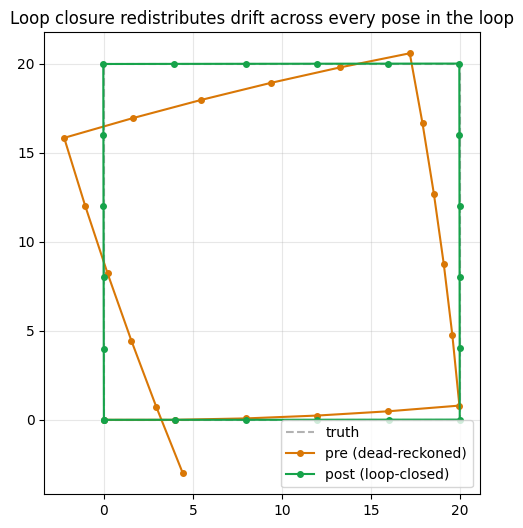

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([p.x for p in truth], [p.y for p in truth], "--", color="grey", alpha=0.6, label="truth")
ax.plot([p.x for p in pre], [p.y for p in pre], "-o", color="#d97706", markersize=4, label="pre (dead-reckoned)")
ax.plot([p.x for p in post], [p.y for p in post], "-o", color="#16a34a", markersize=4, label="post (loop-closed)")
ax.set_aspect("equal")
ax.legend(loc="best")
ax.set_title("Loop closure redistributes drift across every pose in the loop")
ax.grid(True, alpha=0.3)
plt.show()


## Claim — the loop closure collapses end-to-end drift

The measured assertion: post-optimize, the gap between p_last and p0
shrinks by an order of magnitude. The trajectory itself snaps closer to
truth even though we never told the optimizer where ground truth was —
only that the loop should close.


In [5]:
# Direct claim: post-optimize gap is ≥10× smaller than pre.
assert gap_after < gap_before / 10, f"loop closure failed to redistribute drift: pre={gap_before:.3f}, post={gap_after:.3f}"
print(f"OK · pre={gap_before:.3f}m  post={gap_after:.3f}m  ratio={gap_before/max(gap_after, 1e-6):.1f}x")


OK · pre=5.356m  post=0.000m  ratio=1764162.8x


## Limit — naive loop closures can be poisoned

Every constraint we just added was treated as ground truth. In a
Byzantine swarm, an attacker who controls one pose can fabricate
loop-closure factors to drag the joint map. This is what L11 / NB 11
shows: cooperative SLAM with one peer reporting a *lying self-pose*.
The fix (NB 12) is to gate every factor by the reporter's reputation
before letting LM weight it.

**Pointers:**
- ADR 0016 — pose-graph substrate (factor types, LM solver).
- ADR 0017 — loop-closure detection and information weighting.
- `tests/eval/test_slam_integration.py::test_honest_swarm_pose_drift_bounded_over_80_ticks`
  bounds the honest-swarm drift this notebook's setup is the
  pedagogical projection of.
